**Latar belakang**

Penjualan menurun sedangkan stok produk masih banyak

Setup modul

In [28]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

`Dataset dan data uji`

In [7]:
with open("data_penjualan.json", "r") as file:
    data_mentah = json.load(file)

In [10]:
df_latih = pd.DataFrame(data_mentah["dataset_penjualan"])
df_uji = pd.DataFrame(data_mentah["data_uji"])

df_latih.info()
print("\n")
display(df_latih)

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_barang    5 non-null      str    
 1   jumlah_stok  4 non-null      float64
 2   harga        5 non-null      int64  
 3   keputusan    5 non-null      str    
dtypes: float64(1), int64(1), str(2)
memory usage: 292.0 bytes




,id_barang,jumlah_stok,harga,keputusan
0,A,120.0,50000,Diskon
1,B,200.0,120000,Thrift
2,C,NaN,40000,Diskon
3,D,220.0,150000,Thrift
4,E,80.0,60000,Diskon


`EDA`

In [11]:
print(df_latih.isnull().sum())

id_barang      0
jumlah_stok    1
harga          0
keputusan      0
dtype: int64


In [12]:
df_latih.describe()

,jumlah_stok,harga
count,4.000000,5.000000
mean,155.000000,84000.000000
std,66.080759,48270.073545
min,80.000000,40000.000000
25%,110.000000,50000.000000
50%,160.000000,60000.000000
75%,205.000000,120000.000000
max,220.000000,150000.000000


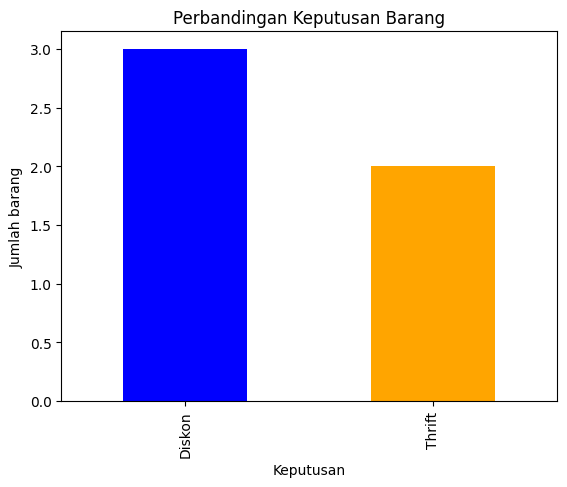

In [14]:
df_latih['keputusan'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title("Perbandingan Keputusan Barang")
plt.xlabel("Keputusan")
plt.ylabel("Jumlah barang")
plt.show()


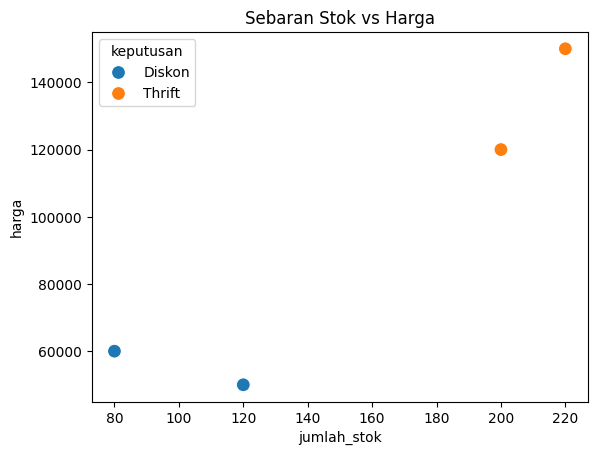

In [16]:
# membuat titik pencaran
sns.scatterplot(data=df_latih, x='jumlah_stok', y='harga', hue='keputusan', s=100)
plt.title("Sebaran Stok vs Harga")
plt.show()

`Pre-Processing`

**Imputasi nilai kosong**

In [19]:
mean_stok = df_latih['jumlah_stok'].mean()
print(mean_stok)

df_latih['jumlah_stok'] = df_latih['jumlah_stok'].fillna(mean_stok)

155.0


In [21]:
display(df_latih)
df_latih.info()

,id_barang,jumlah_stok,harga,keputusan
0,A,120.0,50000,Diskon
1,B,200.0,120000,Thrift
2,C,155.0,40000,Diskon
3,D,220.0,150000,Thrift
4,E,80.0,60000,Diskon


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_barang    5 non-null      str    
 1   jumlah_stok  5 non-null      float64
 2   harga        5 non-null      int64  
 3   keputusan    5 non-null      str    
dtypes: float64(1), int64(1), str(2)
memory usage: 292.0 bytes


`Memisahkan Fitur(X), dan Hasil(Y)`

In [27]:
# data latih
print("Fitur(latih, uji)")
X = df_latih[['jumlah_stok', 'harga']]
display(X)
# data uji
Xf = df_uji[['jumlah_stok', 'harga']]
display(Xf)


print("Target(latih, uji)")
Y = df_latih[['keputusan']]
display(Y)
Yf = df_uji[['keputusan']]
display(Yf)




Fitur(latih, uji)


,jumlah_stok,harga
0,120.0,50000
1,200.0,120000
2,155.0,40000
3,220.0,150000
4,80.0,60000


,jumlah_stok,harga
0,180,130000


Target(latih, uji)


,keputusan
0,Diskon
1,Thrift
2,Diskon
3,Thrift
4,Diskon


,keputusan
0,Thrift


In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)
df = pd.DataFrame(X_norm, columns=X.columns)
print("X norm")
display(df)



X norm


,jumlah_stok,harga
0,0.285714,0.090909
1,0.857143,0.727273
2,0.535714,0.000000
3,1.000000,1.000000
4,0.000000,0.181818


`Modeling (KNN)`

In [36]:
Xf_norm = scaler.transform(Xf)
dff = pd.DataFrame(Xf_norm, columns=Xf.columns)
display(dff)

,jumlah_stok,harga
0,0.714286,0.818182


In [37]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=1)

In [38]:
model_knn.fit(X_norm, Y)


d:\Dokumen coding\Data Science\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [39]:
X_uji = df_uji[['jumlah_stok', 'harga']]
tebakan = model_knn.predict(Xf_norm)
print(f"Hasil tebakan untuk barang F adalah: {tebakan}")

Hasil tebakan untuk barang F adalah: ['Thrift']
